# Floating-point error in PyCBC's CPU chi-square calculation

PyCBC searches for gravitational-wave signals by comparing detector data with waveform templates. Its power chi-square (χ²) test checks how that match is distributed across frequency bands. The CPU routine examined here evaluates those bands at selected times by repeatedly rotating complex numbers and adding them.

**Can rounding in that calculation change the answer appreciably?** This notebook starts with a synthetic input whose exact answer is known, then separates errors from phase rotation, addition and time-index conversion. In the saved run, the bin-power result is **1.01096 instead of 1**, and the resulting χ² is **1.02193 instead of 1**.

`complex64` stores each real and imaginary component as a 32-bit float; `complex128` uses 64-bit components. We compare both using the installed PyCBC CPU implementation.

**Run:** install with `python -m pip install "pycbc==2.11.0" matplotlib jupyterlab`, then **Restart Kernel and Run All**. Tested with [PyCBC 2.11.0](https://pypi.org/project/PyCBC/2.11.0/). The small arithmetic helper is loaded locally or downloaded with a verified hash. Low-order results may vary by machine.

In [1]:
import platform
import warnings

# Silence only LAL's unrelated notebook-output performance notice.
warnings.filterwarnings("ignore", message="Wswiglal-redir-stdio")
import numpy as np
import pycbc
from pycbc.types import Array
from pycbc.scheme import CPUScheme
from pycbc.vetoes.chisq_cpu import shift_sum

print(f"PyCBC {pycbc.__version__}; NumPy {np.__version__}; "
      f"Python {platform.python_version()}; {platform.system()} {platform.machine()}")
assert pycbc.__version__ == '2.11.0'

PyCBC 2.11.0; NumPy 2.3.5; Python 3.13.9; Darwin arm64


## 1. A bin-power calculation with an exact answer

Let `corr[k]` be a frequency-domain correlation coefficient, N the transform length, and t an integer time-sample index. For each frequency bin b, the CPU routine forms a complex sum:

**qᵦ(t) = Σ[k in bin b] corr[k] exp(2πikt/N)**, then returns **S(t) = Σᵦ|qᵦ(t)|²**.

The exponential rotates a complex number without changing its magnitude. Set one coefficient to 1 and every other coefficient to 0: the only nonzero bin must have power 1, so **S = 1** at every time. Placing that coefficient late in a wide bin forces many phase updates before it is used, even though earlier coefficients are zero. This happens within one function call.

The following cell calls PyCBC's `shift_sum` directly; no FFT is performed.

In [2]:
N = 2**20
sample = 100_000
bins = [0, N // 4, N // 2]       # Two equal-width frequency bins.
k = bins[1] - 1                 # Last coefficient of the first bin.
corr = np.zeros(N, dtype=np.complex64)
corr[k] = 1

print(f"{'input':<12} {'output':<10} {'S (expected 1)':>20} {'error (%)':>14}")
powers = {}
with CPUScheme():
    for dtype in (np.complex64, np.complex128):
        result = shift_sum(Array(corr.astype(dtype)), [sample], bins)
        powers[np.dtype(dtype).name] = float(result[0])
        print(f"{np.dtype(dtype).name:<12} {str(result.dtype):<10} "
              f"{result[0]:20.13f} {100 * (float(result[0]) - 1):14.8g}")

    # Controls: no rotation, and double-precision rotation.
    np.testing.assert_array_equal(shift_sum(Array(corr), [0], bins), [1.0])
np.testing.assert_allclose(powers['complex128'], 1.0, rtol=0, atol=1e-8)

input        output           S (expected 1)      error (%)
complex64    float32         1.0109626054764      1.0962605
complex128   float64         1.0000000000025  2.4551472e-10


## 2. How the bin-power error changes chi-square

PyCBC combines the bin powers using **χ² = (pS − |snr|²) × norm²**, where p is the number of bins, `snr` is the unnormalized matched-filter sum at the selected time, and `norm` is its normalization factor.

For this input, p = 2, |snr|² = 1 and norm = 1, so **χ² = 2S − 1 = 1** exactly. Calling PyCBC's chi-square wrapper shows how the error in S propagates to the statistic.

In [3]:
from pycbc.vetoes.chisq import power_chisq_at_points_from_precomputed

snr = np.array([np.exp(2j * np.pi * ((k * sample) % N) / N)], dtype=np.complex128)
chi_square = {}
print(f"{'correlation':<14} {'chi-square (expected 1)':>25} {'error (%)':>14}")
with CPUScheme():
    for dtype in (np.complex64, np.complex128):
        result = power_chisq_at_points_from_precomputed(
            Array(corr.astype(dtype)), snr, 1.0, bins, np.array([sample]))
        value = float(result[0])
        chi_square[np.dtype(dtype).name] = value
        print(f"{np.dtype(dtype).name:<14} {value:25.13f} {100 * (value - 1):14.8g}")

np.testing.assert_allclose(chi_square['complex128'], 1.0, rtol=0, atol=1e-8)

correlation      chi-square (expected 1)      error (%)
complex64                1.0219252109528      2.1925211
complex128               1.0000000000049  4.9102944e-10


## 3. Separate phase rounding from the value of π

The CPU code generates successive phase factors by multiplying by a fixed rotation. Two choices can affect this process: storing and updating the phase in float32, and using the shortened constant `3.141592653` for π.

To separate them, the [arithmetic model](https://github.com/xangma/pycbc/blob/4e06fff52a7181f9cb3e8ffffe5b7a3866827a11/examples/numerics/chisq_error_controls.py) runs all four combinations of float32/float64 phase arithmetic and shortened/float64 π. It follows the CPU algorithm in NumPy; compiler optimizations and numerical libraries can cause differences from the installed extension.

Move one unit-valued coefficient through the bin. The upper panel shows its power error; the lower panel shows its angular error against a directly evaluated phase. Black dots in the upper panel are independent calls to installed PyCBC. The signed logarithmic axes keep small positive and negative errors visible.

In [4]:
from pathlib import Path
from urllib.request import urlopen
import hashlib
import matplotlib.pyplot as plt

# A small, inspectable NumPy model shared by both notebooks; no compiler needed.
helper_name = 'chisq_error_controls.py'
helper_commit = '4e06fff52a7181f9cb3e8ffffe5b7a3866827a11'
helper_sha = 'e582bdbca7184ac59fe96d4058c03d59a4123056a34ce705a397c0a0a1a98954'
local = next((p for p in [Path(helper_name), Path('examples/numerics') / helper_name]
              if p.is_file()), None)
if local is not None:
    source = local.read_bytes()
else:
    url = f'https://raw.githubusercontent.com/xangma/pycbc/{helper_commit}/examples/numerics/{helper_name}'
    with urlopen(url, timeout=60) as response:
        source = response.read()
assert hashlib.sha256(source).hexdigest() == helper_sha
exec(compile(source, helper_name, 'exec'))
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.18, 'lines.linewidth': 1.7})


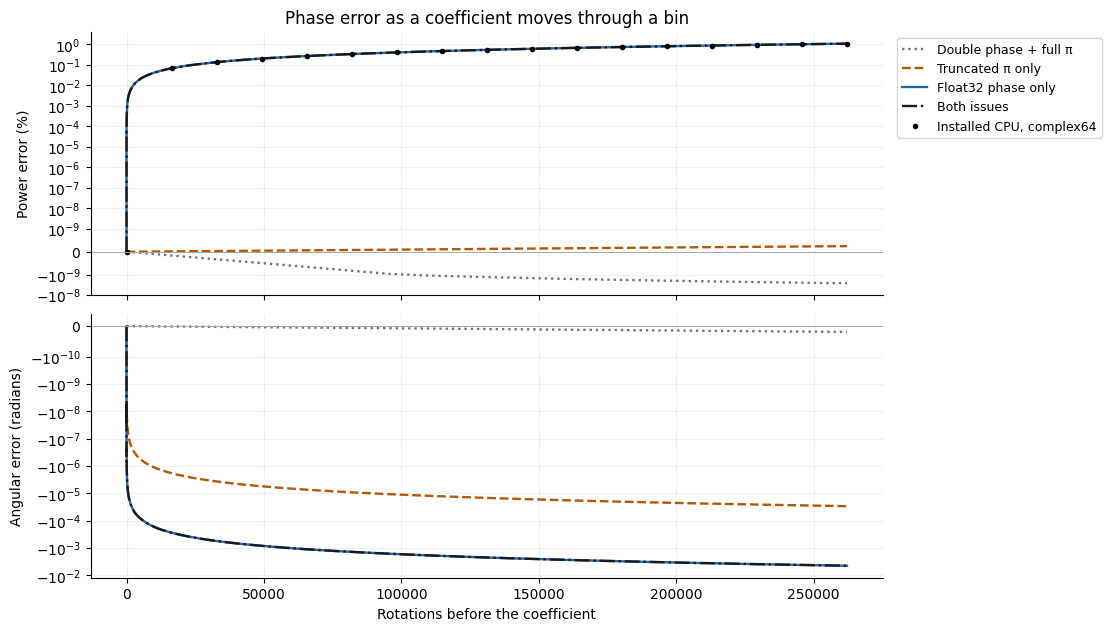

Truncated π alone: measured -2.9489538e-05 rad; analytic prediction -2.9489543e-05 rad


In [5]:
positions = np.unique(np.r_[0, np.geomspace(1, k, 100).astype(int)])
reference_phase = np.exp(2j * np.pi * ((positions.astype(np.int64) * sample) % N) / N)
fig, axes = plt.subplots(2, 1, figsize=(11, 6.2), sharex=True, layout='constrained')
phase_results = {}
for single, short_pi, label, color, style in [
    (False, False, 'Double phase + full π', '0.45', ':'),
    (False, True, 'Truncated π only', COLORS[1], '--'),
    (True, False, 'Float32 phase only', COLORS[2], '-'),
    (True, True, 'Both issues', '0.1', '-.')]:
    phase = phases(N, sample, 0, k+1, single, short_pi)[positions].astype(np.complex128)
    power_error = 100 * (np.abs(phase)**2 - 1)
    angle_error = np.angle(phase / reference_phase)
    phase_results[label] = (power_error, angle_error)
    axes[0].plot(positions, power_error, color=color, ls=style, label=label)
    axes[1].plot(positions, angle_error, color=color, ls=style)

actual_positions = np.linspace(0, k, 17, dtype=int)
with CPUScheme():
    probe = Array(np.zeros(N, dtype=np.complex64))
    actual_power = []
    for position in actual_positions:
        probe[position] = 1
        actual_power.append(float(shift_sum(probe, [sample], bins)[0]))
        probe[position] = 0
axes[0].plot(actual_positions, 100*(np.array(actual_power)-1), 'o', ms=3,
             color='black', label='Installed CPU, complex64')
axes[0].set(yscale='symlog', ylabel='Power error (%)', title='Phase error as a coefficient moves through a bin')
axes[0].set_yscale('symlog', linthresh=1e-9)
axes[1].set_yscale('symlog', linthresh=1e-10)
axes[1].set(ylabel='Angular error (radians)', xlabel='Rotations before the coefficient')
for ax in axes:
    ax.axhline(0, color='0.65', lw=0.7)
    ax.ticklabel_format(axis='x', style='plain', useOffset=False)
axes[0].legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.01, 1))
plt.show()
# The truncated-pi bias has an independent analytic prediction.
predicted_bias = 2 * (3.141592653 - np.pi) * sample * k / N
np.testing.assert_allclose(phase_results['Truncated π only'][1][-1], predicted_bias,
                           rtol=0, atol=1e-9)
print(f'Truncated π alone: measured {phase_results["Truncated π only"][1][-1]:.8g} rad; '
      f'analytic prediction {predicted_bias:.8g} rad')


**Reading the phase plot:** float32 phase updates produce both power and angular errors. Shortening π mainly changes the angle in this example, so a power-only check would miss that effect.

## 4. Test addition and time-index conversion separately

**Addition:** set t = 0 so every phase factor is exactly 1. Add one 1 followed by many terms equal to 2⁻²⁶. Each term is exactly representable, but float32 addition to a running total of 1 discards these small increments. Compare the running power with the known exact sum; installed PyCBC checks both precision endpoints.

**Time-index conversion:** the CPU wrapper converts time indices to the real precision of the input. Float32 cannot represent every integer above 2²⁴. With N = 2²⁶ and two coefficients at frequency indices 0 and N/4, changing t from 2²⁴+1 to its float32 representation changes the exact bin power from 2 to 4. The right panel isolates this conversion using double-precision, directly evaluated phases. It is a synthetic boundary case and needs no large array.

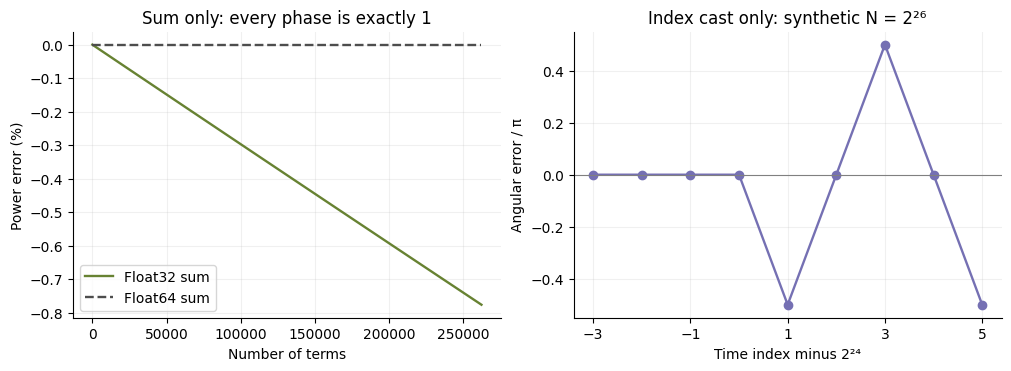

Accumulation-only endpoint: {'complex64': 1.0, 'complex128': 1.007827728870325} ; exact power: 1.007827728870325
Index 16777217 becomes 16777216: two-coefficient power 2 becomes 4


In [6]:
length = 2**18
values = np.full(length, 2.0**-26, dtype=np.float32)
values[0] = 1
counts = np.unique(np.r_[1, np.geomspace(2, length, 100).astype(int)])
exact_power = (1 + (counts-1) * 2.0**-26)**2
sum32_power = np.cumsum(values, dtype=np.float32)[counts-1].astype(np.float64)**2
sum64_power = np.cumsum(values, dtype=np.float64)[counts-1]**2
with CPUScheme():
    cpu_sum = {np.dtype(dt).name: float(shift_sum(Array(values.astype(dt)), [0], [0, length])[0])
               for dt in [np.complex64, np.complex128]}
assert cpu_sum['complex64'] == 1.0
np.testing.assert_allclose(cpu_sum['complex128'], exact_power[-1], rtol=0, atol=1e-14)

large_N, frequency = 2**26, 2**24
indices = 2**24 + np.arange(-3, 6, dtype=np.int64)
rounded_indices = indices.astype(np.float32).astype(np.int64)
exact_phase = np.exp(2j*np.pi*((frequency*indices) % large_N)/large_N)
cast_phase = np.exp(2j*np.pi*((frequency*rounded_indices) % large_N)/large_N)
angle_error = np.angle(cast_phase / exact_phase)
row = int(np.flatnonzero(indices == 2**24+1)[0])
np.testing.assert_allclose(angle_error[row], -np.pi/2, rtol=0, atol=1e-14)
exact_two_term_power, cast_two_term_power = abs(1+exact_phase[row])**2, abs(1+cast_phase[row])**2
np.testing.assert_allclose([exact_two_term_power, cast_two_term_power], [2, 4], atol=1e-14)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), layout='constrained')
for power, label, color, style in [(sum32_power, 'Float32 sum', COLORS[8], '-'),
                                    (sum64_power, 'Float64 sum', '0.3', '--')]:
    axes[0].plot(counts, 100*(power/exact_power-1), color=color, ls=style, label=label)
axes[0].set(xlabel='Number of terms', ylabel='Power error (%)', title='Sum only: every phase is exactly 1')
axes[0].legend()
axes[1].plot(indices-2**24, angle_error/np.pi, 'o-', color='#7570b3')
axes[1].axhline(0, color='0.5', lw=0.8)
axes[1].set(xlabel='Time index minus 2²⁴', ylabel='Angular error / π',
            title='Index cast only: synthetic N = 2²⁶', xticks=[-3, -1, 1, 3, 5])
plt.show()
print('Accumulation-only endpoint:', cpu_sum, '; exact power:', exact_power[-1])
print(f'Index {indices[row]} becomes {rounded_indices[row]}: '
      f'two-coefficient power {exact_two_term_power:g} becomes {cast_two_term_power:g}')


**What the experiments establish:** the installed complex64 routine changes a known bin power and its resulting χ². The phase model separates magnitude drift from angular drift; the t = 0 test demonstrates addition error without phase rotation. Time-index conversion produces a distinct error only when an index changes on conversion.

These are controlled examples, not estimates of typical search errors. A [separate notebook using recorded LIGO Hanford inputs](cpu_chisq_real_data.ipynb) examines several arithmetic effects together and reports their interactions.

Sources: PyCBC 2.11.0 [CPU routine](https://github.com/gwastro/pycbc/blob/v2.11.0/pycbc/vetoes/chisq_cpu.pyx) and [chi-square wrapper](https://github.com/gwastro/pycbc/blob/v2.11.0/pycbc/vetoes/chisq.py).